<a href="https://colab.research.google.com/github/zacknn/MachineLearning/blob/main/models/neural_networks/rnn/RNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
# Import necessary libraries
import numpy as np # For numerical operations, especially for seeding
import torch # The main PyTorch library for building neural networks
import torch.nn as nn # Neural network modules (e.g., layers, activation functions)
import torch.optim as optim # Optimization algorithms (e.g., Adam, SGD)
from collections import Counter # For counting hashable objects (used to build vocabulary)
import matplotlib.pyplot as plt # For plotting and visualization

In [33]:
# Set random seeds for reproducibility across runs
torch.manual_seed(42) # Seed for PyTorch operations
np.random.seed(42) # Seed for NumPy operations

In [34]:
sentences = [
    "the cat sat on the mat",
    "the dog ran in the park",
    "the bird flew over the tree",
    "the fish swam in the water",
    "the sun shines on the earth",
    "the moon glows in the night",
    "the stars twinkle in the sky",
    "the rain falls on the ground",
    "the wind blows through the trees",
    "the snow covers the mountain",
    "the cat sleeps on the bed",
    "the dog plays in the garden",
    "the bird sings in the morning",
    "the fish jumps out of water",
    "the sun sets behind the hills",
    "the moon rises over the ocean",
    "the stars shine in the darkness",
    "the rain stops after the storm",
    "the wind calms in the evening",
    "the snow melts in the spring"
]

print("Dataset Overview:")
print(f"Total sentences: {len(sentences)}") # Print the total number of sentences in the dataset
print("Sample sentences:")
# Print the first 3 sample sentences for a quick overview
for i, sent in enumerate(sentences[:3]):
    print(f"  {i+1}. {sent}")

Dataset Overview:
Total sentences: 20
Sample sentences:
  1. the cat sat on the mat
  2. the dog ran in the park
  3. the bird flew over the tree


In [35]:
# Tokenize sentences and build the vocabulary
all_words = [] # Initialize a list to hold all words from all sentences
for sent in sentences:
    all_words.extend(sent.split()) # Split each sentence into words and add to the list

# Count word frequencies to understand distribution and potentially filter rare words (not done here)
word_counts = Counter(all_words)

# Define special tokens and combine them with unique words to form the vocabulary
vocab = [
    '<PAD>', # Padding token: used to make sequences of equal length
    '<UNK>', # Unknown token: for words not seen during training
    '<START>', # Start-of-sequence token
    '<END>' # End-of-sequence token
] + sorted(word_counts.keys()) # Add all unique words from the dataset, sorted alphabetically

# Create mappings from word to index and index to word
word2idx = {word: idx for idx, word in enumerate(vocab)} # Dictionary mapping words to their numerical IDs
idx2word = {idx: word for word, idx in word2idx.items()} # Dictionary mapping numerical IDs back to words

vocab_size = len(vocab) # Calculate the total size of the vocabulary (including special tokens)
print(f"\nVocabulary size: {vocab_size}")
print(f"Unique words: {len(word_counts)}")


Vocabulary size: 62
Unique words: 58


In [36]:
def prepare_sequence(text, word2idx):
    """Convert raw text into a sequence of numerical indices.

    Args:
        text (str): The input sentence string.
        word2idx (dict): A dictionary mapping words to their integer indices.

    Returns:
        list: A list of integer indices representing the input sentence,
              with <START> and <END> tokens added.
    """
    tokens = ['<START>'] + text.split() + ['<END>'] # Add start/end tokens and split sentence into words
    # Map each token to its index; use <UNK> token's index if word is not in vocab
    indices = [word2idx.get(token, word2idx['<UNK>']) for token in tokens]
    return indices

# Create input-target pairs for next-word prediction
# For example, if a sequence is [w1, w2, w3, w4]:
#   - Input: [w1] -> Target: w2
#   - Input: [w1, w2] -> Target: w3
#   - Input: [w1, w2, w3] -> Target: w4
X_train = []  # List to store input sequences (prefixes)
y_train = []  # List to store target words (the next word to predict)

for sent in sentences:
    seq = prepare_sequence(sent, word2idx) # Convert the sentence to a sequence of indices
    # Create sliding windows for each possible prefix-next_word pair
    for i in range(len(seq) - 1):
        X_train.append(seq[:i+1])   # Input is the sequence from start up to current word (inclusive)
        y_train.append(seq[i+1])    # Target is the next word in the sequence

print(f"\nTraining examples created: {len(X_train)}")
print(f"Example input-output pairs:")
# Display the first 3 example input-target pairs for illustration
for i in range(3):
    # Convert indices back to words for human readability
    input_words = [idx2word[idx] for idx in X_train[i]]
    target_word = idx2word[y_train[i]]
    print(f"  Input: {' '.join(input_words)} -> Target: {target_word}")


Training examples created: 139
Example input-output pairs:
  Input: <START> -> Target: the
  Input: <START> the -> Target: cat
  Input: <START> the cat -> Target: sat


In [37]:
class SimpleRNN(nn.Module):
    """
    A simple Vanilla RNN (Recurrent Neural Network) for next-word prediction.

    Architecture:
    - Embedding Layer: Converts word indices into dense, continuous vector representations.
    - RNN Layer: Processes the sequence of embedded words, maintaining a hidden state
                 that captures information about past words.
    - Linear Layer: Maps the final hidden state (or hidden states for each time step)
                    to the vocabulary space to predict the next word.
    """

    def __init__(self, vocab_size, embedding_dim=16, hidden_dim=32):
        """
        Initializes the SimpleRNN model.

        Args:
            vocab_size (int): The total number of unique words in the vocabulary.
            embedding_dim (int): The dimension of the word embeddings (size of each word vector).
            hidden_dim (int): The dimension of the hidden state in the RNN.
        """
        super(SimpleRNN, self).__init__()
        self.hidden_dim = hidden_dim # Store hidden dimension for initializing hidden state
        self.vocab_size = vocab_size # Store vocabulary size for output layer

        # Embedding layer: Converts integer word IDs into dense vectors
        # `padding_idx=0` means the word at index 0 (<PAD> token) will be mapped to a zero vector.
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # RNN layer: The core recurrent component
        # `input_size`: Size of the input features, which is `embedding_dim`.
        # `hidden_size`: Size of the hidden state output at each time step.
        # `batch_first=True`: Specifies that the input/output tensors will have batch dimension first
        #                     (batch_size, sequence_length, feature_size).
        # `nonlinearity='tanh'`: Uses the hyperbolic tangent activation function in the RNN cell.
        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            nonlinearity='tanh'
        )

        # Output layer (Fully Connected Layer): Maps the RNN's hidden state to the vocabulary space
        # The output size is `vocab_size` because we want to predict probabilities for each word in the vocabulary.
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        """
        Performs a forward pass through the SimpleRNN.

        Args:
            x (torch.Tensor): Input tensor of word indices, shape (batch_size, seq_length).
            hidden (torch.Tensor, optional): The initial hidden state of the RNN.
                                             If None, it defaults to zeros. Shape (1, batch_size, hidden_dim).

        Returns:
            tuple: A tuple containing:
                - output (torch.Tensor): Logits for each word at each time step,
                                         shape (batch_size, seq_length, vocab_size).
                - hidden (torch.Tensor): The final hidden state of the RNN for the entire sequence,
                                        shape (1, batch_size, hidden_dim).
        """
        batch_size = x.size(0)

        # Step 1: Embedding lookup
        # Input `x` (batch_size, seq_len) -> `embedded` (batch_size, seq_len, embed_dim)
        embedded = self.embedding(x)

        # Step 2: RNN processing
        # `rnn_out`: Output features from the last layer of the RNN for each time step.
        #            Shape: (batch_size, seq_len, hidden_dim).
        # `hidden`: The final hidden state for each element in the batch.
        #           Shape: (num_layers * num_directions, batch_size, hidden_dim). For simple RNN, num_layers=1, num_directions=1.
        rnn_out, hidden = self.rnn(embedded, hidden)

        # Step 3: Linear projection to vocabulary space
        # `output`: Logits (raw scores) for each word in the vocabulary at each time step.
        #           Shape: (batch_size, seq_len, vocab_size).
        output = self.fc(rnn_out)

        return output, hidden

    def init_hidden(self, batch_size):
        """
        Initializes the hidden state of the RNN with zeros.

        Args:
            batch_size (int): The current batch size.

        Returns:
            torch.Tensor: A tensor of zeros with shape (1, batch_size, self.hidden_dim)
                          representing the initial hidden state.
        """
        # RNN hidden state typically has shape (num_layers * num_directions, batch_size, hidden_size)
        # For a simple, unidirectional RNN, num_layers=1, num_directions=1.
        return torch.zeros(1, batch_size, self.hidden_dim)

In [38]:
# Define Hyperparameters for the model and training process
EMBEDDING_DIM = 16  # Dimension of the word embeddings
HIDDEN_DIM = 32     # Dimension of the RNN's hidden state
LEARNING_RATE = 0.01 # Learning rate for the optimizer
EPOCHS = 200        # Number of training epochs
BATCH_SIZE = 1      # For simplicity, training one sequence at a time (batch size of 1)

# Initialize the SimpleRNN model with the defined parameters
model = SimpleRNN(vocab_size, EMBEDDING_DIM, HIDDEN_DIM)

# Define the loss function
# CrossEntropyLoss is suitable for multi-class classification (predicting one word out of vocab_size words)
criterion = nn.CrossEntropyLoss()

# Define the optimizer
# Adam optimizer is a popular choice for deep learning models
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"\nModel Architecture:")
print(model) # Print the model's structure

# Calculate and print the total number of trainable parameters in the model
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")


Model Architecture:
SimpleRNN(
  (embedding): Embedding(62, 16, padding_idx=0)
  (rnn): RNN(16, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=62, bias=True)
)

Total parameters: 4638


In [39]:
def train_rnn():
    """
    Trains the SimpleRNN model for next-word prediction.

    The function iterates through a specified number of epochs, and within each epoch,
    it processes all training examples. It calculates loss, performs backpropagation,
    updates model weights, and tracks average loss and accuracy.

    Returns:
        list: A list containing the average loss for each epoch.
    """
    model.train() # Set the model to training mode (e.g., enables dropout if used)
    losses = []   # List to store average loss per epoch

    print("\n" + "="*50)
    print("TRAINING START")
    print("="*50)

    for epoch in range(EPOCHS):
        total_loss = 0 # Accumulator for loss over the current epoch
        correct = 0    # Accumulator for correct predictions
        total = 0      # Accumulator for total predictions

        for i in range(len(X_train)): # Iterate through each training example
            # Prepare input sequence (X) and target word (y)
            # `X_train[i]` is a list of indices, wrap it in a list to create batch dimension (1, seq_len)
            x = torch.tensor([X_train[i]], dtype=torch.long)  # Input shape: (1, seq_len)
            # `y_train[i]` is a single index, wrap it in a list to create batch dimension (1,)
            y = torch.tensor([y_train[i]], dtype=torch.long)  # Target shape: (1,)

            # Initialize hidden state for each sequence (important for non-truncated BPTT on single sequences)
            hidden = model.init_hidden(1) # Batch size is 1 here

            # Zero out gradients from the previous step
            optimizer.zero_grad() # Clear previous gradients before computing new ones

            # Forward pass: get model output and updated hidden state
            output, hidden = model(x, hidden)

            # The output tensor has shape (batch_size, seq_len, vocab_size)
            # For next-word prediction, we are interested in the prediction for the *last* word in the input sequence.
            last_output = output[:, -1, :]  # Select the predictions for the last time step: (1, vocab_size)

            # Calculate the loss between the predicted logits and the true target word
            loss = criterion(last_output, y)

            # Backward pass: compute gradients of the loss with respect to model parameters
            loss.backward()

            # Update model weights using the optimizer
            optimizer.step()

            total_loss += loss.item() # Add current batch loss to total epoch loss

            # Calculate accuracy for monitoring
            predicted = last_output.argmax(dim=1) # Get the index of the highest probability word
            correct += (predicted == y).sum().item() # Increment correct count if prediction matches target
            total += 1 # Increment total count

        avg_loss = total_loss / len(X_train) # Calculate average loss for the epoch
        accuracy = correct / total # Calculate accuracy for the epoch
        losses.append(avg_loss) # Store the average loss

        # Print training progress at specified intervals or at the first epoch
        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}] "
                  f"Loss: {avg_loss:.4f} | Accuracy: {accuracy:.4f}")

    return losses

# Run the training process and store the returned losses
losses = train_rnn()


TRAINING START
Epoch [1/200] Loss: 3.0039 | Accuracy: 0.4101
Epoch [20/200] Loss: 1.2340 | Accuracy: 0.6043
Epoch [40/200] Loss: 0.9870 | Accuracy: 0.6763
Epoch [60/200] Loss: 0.9220 | Accuracy: 0.7050
Epoch [80/200] Loss: 0.9190 | Accuracy: 0.6978
Epoch [100/200] Loss: 0.9182 | Accuracy: 0.6978
Epoch [120/200] Loss: 0.8825 | Accuracy: 0.7122
Epoch [140/200] Loss: 0.8882 | Accuracy: 0.7122
Epoch [160/200] Loss: 0.8841 | Accuracy: 0.7122
Epoch [180/200] Loss: 0.8943 | Accuracy: 0.7050
Epoch [200/200] Loss: 0.8831 | Accuracy: 0.7122


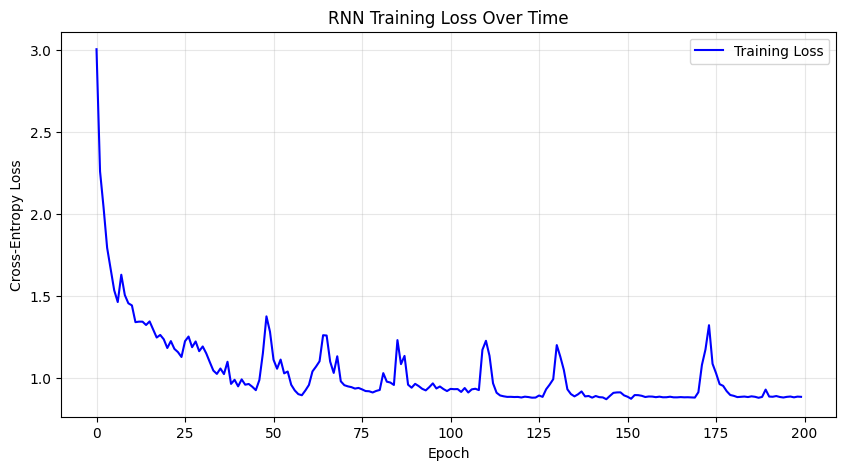

In [40]:
# Plot the training loss over epochs to visualize learning progression
plt.figure(figsize=(10, 5)) # Set the figure size for better readability
plt.plot(losses, label='Training Loss', color='blue') # Plot the list of losses
plt.xlabel('Epoch') # Label for the x-axis
plt.ylabel('Cross-Entropy Loss') # Label for the y-axis
plt.title('RNN Training Loss Over Time') # Title of the plot
plt.legend() # Display the legend for the plotted line
plt.grid(True, alpha=0.3) # Add a subtle grid for easier reading of values
plt.show() # Display the plot

In [41]:
def predict_next_word(model, input_text, word2idx, idx2word):
    """
    Predicts the top 5 most probable next words given an input sequence.

    Args:
        model (nn.Module): The trained RNN model.
        input_text (str): The input sentence prefix (e.g., "the cat").
        word2idx (dict): Dictionary mapping words to their integer indices.
        idx2word (dict): Dictionary mapping integer indices back to words.

    Returns:
        list: A list of tuples, where each tuple contains (predicted_word, probability).
              Sorted by probability in descending order.
    """
    model.eval() # Set the model to evaluation mode (disables dropout, batchnorm updates, etc.)

    with torch.no_grad(): # Disable gradient calculations during inference to save memory and speed up computation
        # Prepare input: add <START> token and convert words to indices
        tokens = ['<START>'] + input_text.split() # Split input_text into words and prepend <START>
        # Convert tokens to numerical indices; use <UNK> for unseen words
        indices = [word2idx.get(token, word2idx['<UNK>']) for token in tokens]
        # Convert list of indices to a PyTorch tensor, adding a batch dimension
        x = torch.tensor([indices], dtype=torch.long) # Shape: (1, seq_len)

        # Initialize hidden state with zeros for the prediction
        hidden = model.init_hidden(1) # Batch size is 1 for a single prediction

        # Forward pass through the model
        output, hidden = model(x, hidden)

        # Get the output (logits) for the last time step of the sequence
        last_output = output[:, -1, :] # Shape: (1, vocab_size)
        # Apply softmax to convert logits into probability distribution over the vocabulary
        probabilities = torch.softmax(last_output, dim=1)

        # Get the top 5 most probable words and their probabilities
        top5_probs, top5_indices = torch.topk(probabilities, 5) # `topk` returns values and indices

        predictions = [] # List to store (word, probability) tuples
        # Iterate through the top 5 predictions and format them
        for prob, idx in zip(top5_probs[0], top5_indices[0]):
            word = idx2word[idx.item()] # Convert index back to word
            predictions.append((word, prob.item())) # Store word and its probability

    return predictions

# --- Test the prediction function with various input phrases ---
print("\n" + "="*50)
print("PREDICTION EXAMPLES")
print("="*50)

test_inputs = [
    "the cat",
    "the dog",
    "the sun",
    "the moon",
    "the rain"
]

# Loop through each test input and print its top 5 next-word predictions
for input_text in test_inputs:
    preds = predict_next_word(model, input_text, word2idx, idx2word)
    print(f"\nInput: '{input_text}'")
    print("Top 5 predictions:")
    for word, prob in preds:
        print(f"  {word}: {prob:.4f}") # Print each prediction with 4 decimal places for probability


PREDICTION EXAMPLES

Input: 'the cat'
Top 5 predictions:
  sleeps: 0.8833
  sat: 0.0313
  stops: 0.0256
  plays: 0.0166
  falls: 0.0121

Input: 'the dog'
Top 5 predictions:
  plays: 0.9127
  ran: 0.0590
  sleeps: 0.0116
  bed: 0.0040
  covers: 0.0027

Input: 'the sun'
Top 5 predictions:
  sets: 0.9333
  shines: 0.0648
  covers: 0.0005
  plays: 0.0004
  sleeps: 0.0003

Input: 'the moon'
Top 5 predictions:
  rises: 0.8641
  glows: 0.0999
  morning: 0.0275
  water: 0.0045
  stops: 0.0012

Input: 'the rain'
Top 5 predictions:
  stops: 0.8727
  falls: 0.1112
  rises: 0.0055
  sings: 0.0028
  glows: 0.0020



Visualizing hidden state evolution...


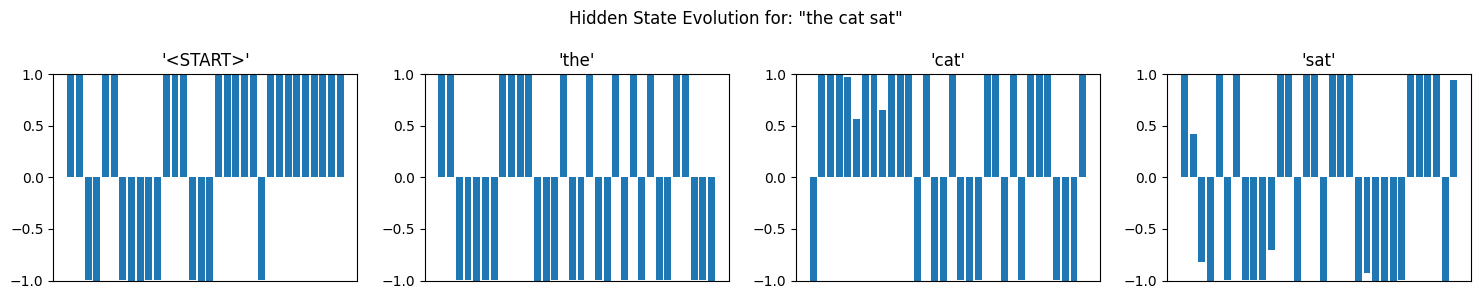

[array([[ 0.9999999 ,  1.        , -0.9999981 , -1.        ,  1.        ,
          1.        , -0.99989134, -1.        , -1.        , -0.9991583 ,
         -0.9987911 ,  1.        ,  1.        ,  0.9999998 , -0.9999018 ,
         -1.        , -1.        ,  1.        ,  1.        ,  0.9999841 ,
          0.9999666 ,  0.9999969 , -0.99999815,  0.9999999 ,  1.        ,
          0.99832433,  0.9999309 ,  1.        ,  1.        ,  1.        ,
          0.9999726 ,  1.        ],
        [ 0.9999471 ,  0.998529  , -0.9984393 , -0.9999995 , -1.        ,
         -0.9999953 , -0.99999565,  0.9998992 ,  0.99999994,  0.99999464,
          1.        , -1.        , -1.        , -0.99969244,  1.        ,
         -0.99999994, -0.9997679 ,  1.        , -0.9982831 , -1.        ,
          0.9999998 , -0.9990285 ,  1.        , -0.9997917 ,  1.        ,
         -0.99999976, -0.9999988 ,  1.        ,  0.9999951 , -0.9999583 ,
         -0.9999987 , -1.        ],
        [-1.        ,  1.        ,  0.99

In [42]:
def visualize_hidden_states(model, input_text, word2idx):
    """
    Visualizes the evolution of the RNN's hidden states as it processes an input sequence.

    This function uses a PyTorch forward hook to capture the hidden states from the
    RNN layer at each time step and then plots them.

    Args:
        model (nn.Module): The trained RNN model.
        input_text (str): The input sequence to visualize (e.g., "the cat sat").
        word2idx (dict): Dictionary mapping words to their integer indices.

    Returns:
        list: A list containing the captured hidden states for each token in the sequence.
    """
    model.eval() # Set the model to evaluation mode

    # Prepare input text: add <START> token and convert to indices
    tokens = ['<START>'] + input_text.split()
    indices = [word2idx.get(token, word2idx['<UNK>']) for token in tokens]
    x = torch.tensor([indices], dtype=torch.long) # Input tensor (1, seq_len)

    hidden_states = [] # List to store hidden states captured by the hook

    # Define a hook function that will be called after the `model.rnn` module executes.
    # It captures the hidden states output by the RNN layer.
    def hook_fn(module, input, output):
        # For an RNN, `output` is a tuple (output_features, final_hidden_state).
        # We want `output_features` which are the hidden states at each time step.
        # `squeeze()` removes dimensions of size 1 (e.g., batch_size if it's 1).
        # `.numpy()` converts the tensor to a NumPy array for plotting.
        hidden_states.append(output[0].squeeze().numpy())

    # Register the hook on the `model.rnn` layer
    # The hook will be executed after `model.rnn`'s `forward` method.
    handle = model.rnn.register_forward_hook(hook_fn)

    with torch.no_grad(): # Disable gradient computation during visualization
        hidden = model.init_hidden(1) # Initialize hidden state
        output, hidden = model(x, hidden) # Perform a forward pass

    handle.remove() # Remove the hook after use to avoid side effects in subsequent operations

    # Plot the evolution of hidden states for each token
    # Create subplots: one for each token in the input sequence
    fig, axes = plt.subplots(1, len(tokens), figsize=(15, 3))

    # Iterate through each token and its corresponding hidden state
    for i, (token, state) in enumerate(zip(tokens, hidden_states[0])):
        # Ensure axes is iterable even if there's only one subplot
        ax = axes[i] if len(tokens) > 1 else axes
        ax.bar(range(len(state)), state) # Plot hidden state values as a bar chart
        ax.set_title(f"'{token}'") # Set title for each subplot (the token word)
        ax.set_ylim(-1, 1) # Set y-axis limits for consistent visualization across states
        ax.set_xticks([]) # Remove x-axis ticks (as they are just indices of hidden_dim)

    plt.suptitle(f'Hidden State Evolution for: "{input_text}"') # Main title for the entire figure
    plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
    plt.show() # Display the plot

    return hidden_states

# --- Visualize hidden state evolution for a sample phrase ---
print("\nVisualizing hidden state evolution...")
visualize_hidden_states(model, "the cat sat", word2idx)

In [43]:
def generate_text(model, start_text, word2idx, idx2word, max_length=10):
    """
    Generates a sequence of text by repeatedly predicting the next word.

    The model uses its learned patterns to extend an initial `start_text`.

    Args:
        model (nn.Module): The trained RNN model.
        start_text (str): The initial text sequence to start generation from (e.g., "the").
        word2idx (dict): Dictionary mapping words to their integer indices.
        idx2word (dict): Dictionary mapping integer indices back to words.
        max_length (int, optional): The maximum number of words to generate. Defaults to 10.

    Returns:
        str: The generated text, starting with `start_text` and extended by the model.
    """
    model.eval() # Set the model to evaluation mode
    words = start_text.split() # Initialize the list of words with the starting text

    with torch.no_grad(): # Disable gradient calculations for inference
        for _ in range(max_length): # Loop for a maximum of `max_length` predictions
            # Prepare input: current sequence of words + <START> token, converted to indices
            tokens = ['<START>'] + words # Prepend <START> token to the current sequence
            # Convert tokens to numerical indices; use <UNK> for unseen words
            indices = [word2idx.get(token, word2idx['<UNK>']) for token in tokens]
            # Convert list of indices to a PyTorch tensor, adding a batch dimension
            x = torch.tensor([indices], dtype=torch.long) # Input shape: (1, current_seq_len)

            hidden = model.init_hidden(1) # Initialize hidden state for the new input
            output, hidden = model(x, hidden) # Forward pass to get predictions

            # Get the logits for the last time step (predicting the next word)
            last_output = output[:, -1, :] # Shape: (1, vocab_size)
            # Convert logits to probabilities using softmax
            probs = torch.softmax(last_output, dim=1)

            # Choose the next word: here, we take the word with the highest probability (greedy approach)
            next_word_idx = torch.argmax(probs, dim=1).item() # Get the index of the most probable word
            next_word = idx2word[next_word_idx] # Convert index back to word

            # Stop generation if the model predicts the <END> token
            if next_word == '<END>':
                break

            words.append(next_word) # Add the predicted word to the sequence

    return ' '.join(words) # Join all words to form the generated sentence string

print("\n" + "="*50)
print("TEXT GENERATION")
print("="*50)

seeds = ["the", "the cat", "the sun"] # Define starting phrases (seeds) for text generation
for seed in seeds:
    # Generate text using the trained model
    generated = generate_text(model, seed, word2idx=word2idx, idx2word=idx2word, max_length=5)
    print(f"Seed: '{seed}' -> Generated: '{generated}'") # Print the seed and the generated text

print("\n" + "="*50)
print("EXPLANATION OF RNN BEHAVIOR")
print("="*50)


TEXT GENERATION
Seed: 'the' -> Generated: 'the wind calms in the evening'
Seed: 'the cat' -> Generated: 'the cat sleeps over the night'
Seed: 'the sun' -> Generated: 'the sun sets behind the hills'

EXPLANATION OF RNN BEHAVIOR
